In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import ttest_ind, ttest_rel

In [ ]:
def add_pvalues_paired(ax, pairs:dict[str:tuple[list]], alpha=0.05, width:float=0.5, height:float=0.01, color:str="black", print_p:bool=True):
    assert len(ax.get_xticks()) == len(pairs.keys())
    
    # dict mapping label to x position
    x_ticks = {x.get_text():x.get_position()[0] for x in ax.get_xticklabels()}
    y_tick = ax.get_yticks()[-1]

    for k,(x,y) in pairs.items():
        p = ttest_ind(x,y).pvalue
        text = ""
        if print_p:
            text += f"p={np.round(p,3)}"
        if p<alpha:
            text += ("*"*int(-np.log10(p).round(0)))
        
        if text:
            x_tick = x_ticks[k]

            # plot horizontal line
            ax.plot([x_tick-width/2,x_tick+width/2], [y_tick,]*2, c=color, linewidth=0.5)
            # plot vertical lines
            ax.plot([x_tick-width/2,]*2, [y_tick-height, y_tick], c=color, linewidth=0.5)
            ax.plot([x_tick+width/2,]*2, [y_tick-height, y_tick], c=color, linewidth=0.5)
            
            # plot text
            ax.text(x=x_tick, y=y_tick+0.005, s=text, horizontalalignment="center", c=color)

    return ax
def add_pvalues_paired(ax, pairs:dict[str:tuple[list]], alpha=0.05, width:float=0.5, height:float=0.01, color:str="black", print_p:bool=True):
    assert len(ax.get_xticks()) == len(pairs.keys())
    
    # dict mapping label to x position
    x_ticks = {x.get_text():x.get_position()[0] for x in ax.get_xticklabels()}
    y_tick = ax.get_yticks()[-1]

    for k,(x,y) in pairs.items():
        p = ttest_ind(x,y).pvalue
        text = ""
        if print_p:
            text += f"p={np.round(p,3)}"
        if p<alpha:
            text += ("*"*int(-np.log10(p).round(0)))
        
        if text:
            x_tick = x_ticks[k]

            # plot horizontal line
            ax.plot([x_tick-width/2,x_tick+width/2], [y_tick,]*2, c=color, linewidth=0.5)
            # plot vertical lines
            ax.plot([x_tick-width/2,]*2, [y_tick-height, y_tick], c=color, linewidth=0.5)
            ax.plot([x_tick+width/2,]*2, [y_tick-height, y_tick], c=color, linewidth=0.5)
            
            # plot text
            ax.text(x=x_tick, y=y_tick+0.005, s=text, horizontalalignment="center", c=color)

    return ax

In [ ]:
df = pd.read_csv(r"/p/home/jusers/toulouse1/juwels/project/toulouse1/flexcraft/data/o1_iptm_scoring/20260410_135500_af:model_2_multimer_v3_clip:False_nrecycle:4/ipTM_data.csv", header=0, index_col=0)
df = df[~df.index.isna()]
#mask = (df["KD (nM)"]<2000)
#mask = mask.fillna(True)
#df = df.loc[mask]
df = df.astype(
    {
    "scaffold":str,
    "ipTM":float,
    "default_iptm":float,
    "ab_iptm":float,
    "HCDR1":str,
    "HCDR2":str,
    "HCDR3":str,
    "KD (nM)":float,
    }
)
df = df.fillna(df["KD (nM)"].max())
df["Binder"] = df["Binder"].map(lambda x: x=="True")
#df = df.loc[df["scaffold"]!="HER2"]
df.scaffold.value_counts()


scaffold
C5         198
TNFRSF9    185
IL17A      179
IL36R      177
HER2       177
ACVR2B      97
TSLP        88
FXI         62
Name: count, dtype: int64

scaffold            str
ipTM            float64
default_iptm    float64
ab_iptm         float64
HCDR1               str
HCDR2               str
HCDR3               str
KD (nM)         float64
Binder             bool
dtype: object

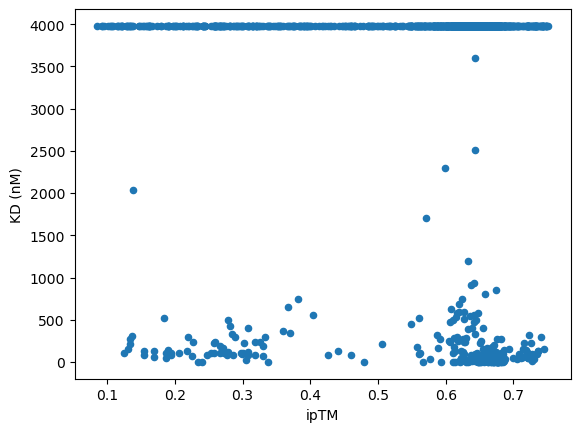

In [ ]:
df.plot("ipTM", "KD (nM)", kind="scatter")
df.dtypes

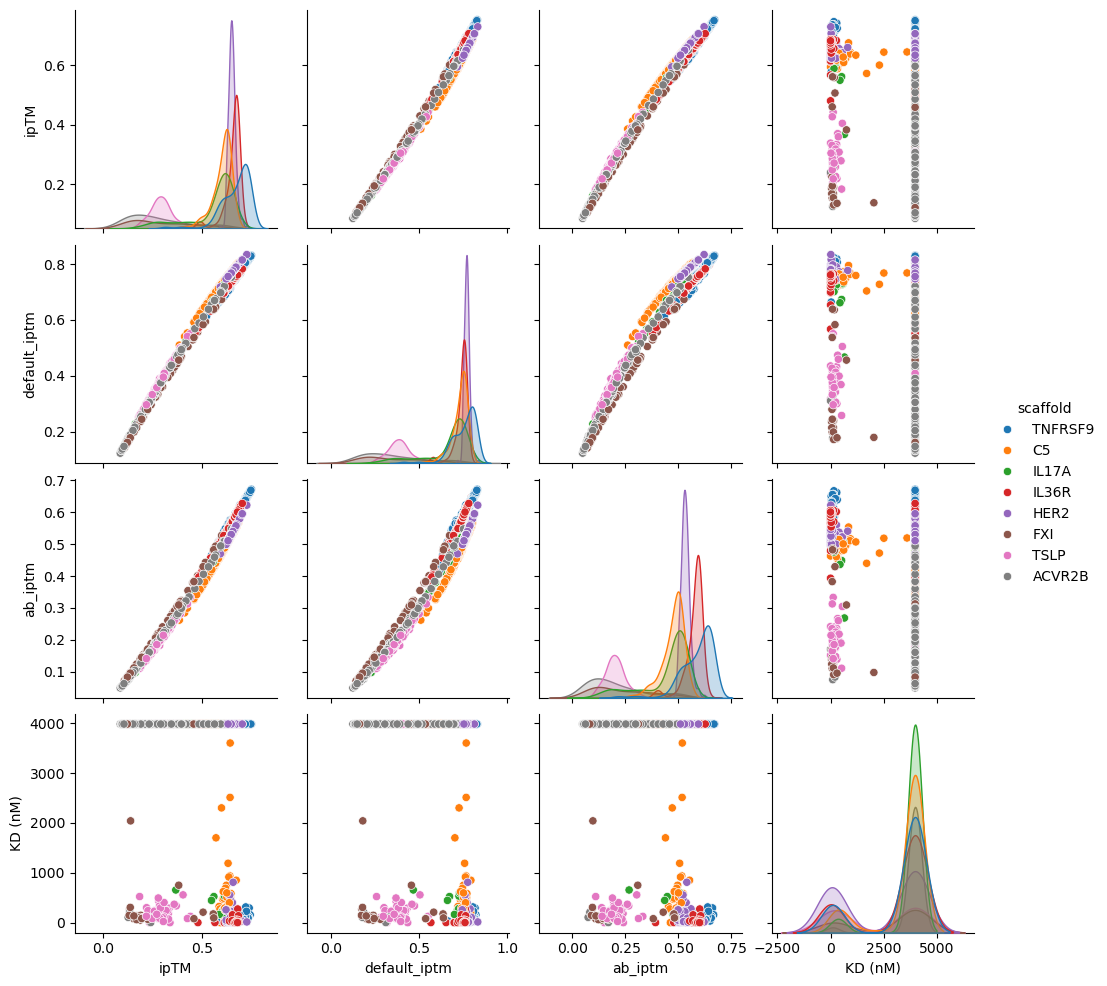

In [ ]:
#n=6
#print(df.scaffold.unique()[n])

sns.pairplot(df,#.query(f"scaffold=='{df.scaffold.unique()[n]}'"),
    hue="scaffold",
    vars=[c for c in df.columns if "KD" in c or "iptm" in c.lower()],
    dropna=True,
    )


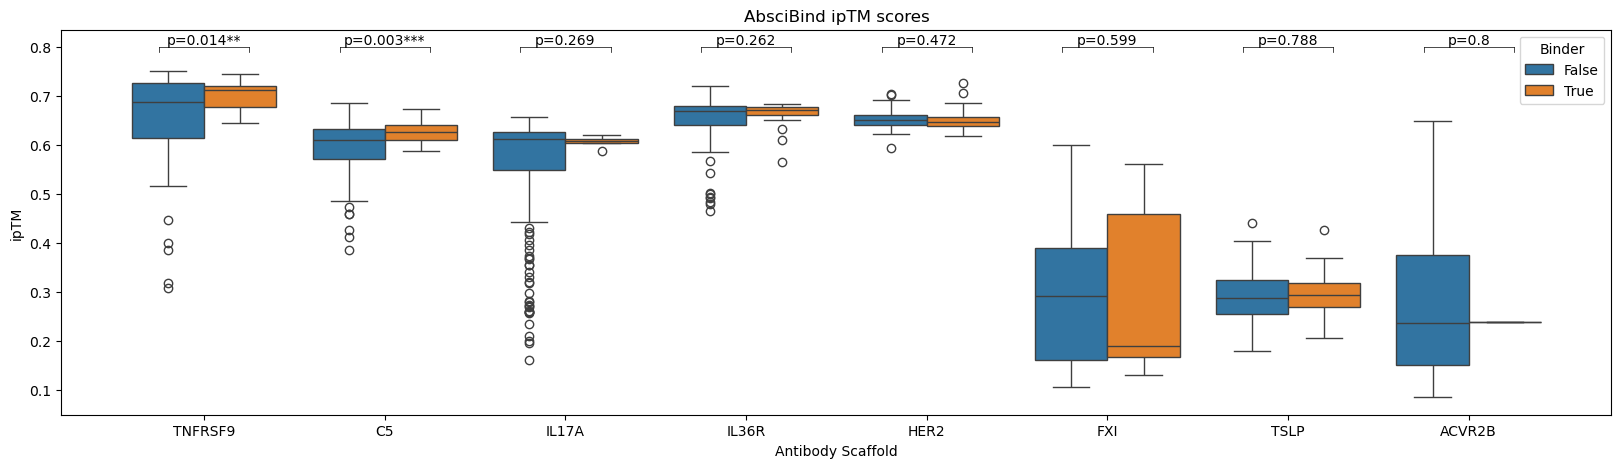

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(20,5))
sns.boxplot(
    df,
    x = "scaffold",
    y = "ipTM",
    hue = "Binder",
    #inner = "point",
    #width = 1,
    ax = ax,
)
ax.set_title("AbsciBind ipTM scores")
ax.set_xlabel("Antibody Scaffold")
grouped = df.groupby(["scaffold", "Binder"]).agg(list)
pairs = {n[0]:(*grouped.loc[n[0], "ipTM"],) for n, r in grouped.iterrows()}
add_pvalues_paired(ax, pairs, print_p=True)
fig.savefig(f"{ax.get_title()}.pdf")

In [ ]:
df = pd.read_csv("/home/hgf_dkfz/hgf_dsb0249/workspaces/haicwork/hgf_dsb0249-BinderDesign/flexcraft/data/o1_iptm_scoring/20260410_112045_fig13_af:model_2_multimer_v3_clip:False_nrecycle:0/ipTM_data.csv", index_col=0)
df

,scaffold,ipTM,default_iptm,ab_iptm
0,7PA9,0.328881,0.389817,0.267945
0,7Q6C,0.724430,0.807467,0.641393
0,7REW,0.559673,0.684521,0.434826
0,7SEG,0.577308,0.675874,0.478743
0,7UVF,0.762566,0.856006,0.669126
0,7UXL,0.388315,0.470386,0.306244
0,7VGS,0.683964,0.764280,0.603648
0,8G3P,0.327364,0.372148,0.282579
0,8GKL,0.203368,0.279541,0.127195
0,8K0D,0.744834,0.788481,0.701188


In [ ]:
ctrl = pd.Series(
    [
        0.75,
        0.9,
        0.9,
        0.75,
        0.9,
        0.9,
        0.9,
        0.75,
        0.9,
        0.9,
        0.8,
        0.8,
        0.9,
        0.9,
        0.9
    ],
    index=df.scaffold)
df["ctrl"] = ctrl.values
df

,scaffold,ipTM,default_iptm,ab_iptm,ctrl
0,7PA9,0.328881,0.389817,0.267945,0.75
0,7Q6C,0.724430,0.807467,0.641393,0.90
0,7REW,0.559673,0.684521,0.434826,0.90
0,7SEG,0.577308,0.675874,0.478743,0.75
0,7UVF,0.762566,0.856006,0.669126,0.90
0,7UXL,0.388315,0.470386,0.306244,0.90
0,7VGS,0.683964,0.764280,0.603648,0.90
0,8G3P,0.327364,0.372148,0.282579,0.75
0,8GKL,0.203368,0.279541,0.127195,0.90
0,8K0D,0.744834,0.788481,0.701188,0.90


/hkfs/work/workspace_haic/scratch/hgf_dsb0249-BinderDesign/miniforge3/envs/plotting/lib/python3.14/site-packages/pandas/plotting/_matplotlib/core.py:1388: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


<Axes: xlabel='ipTM', ylabel='ctrl'>

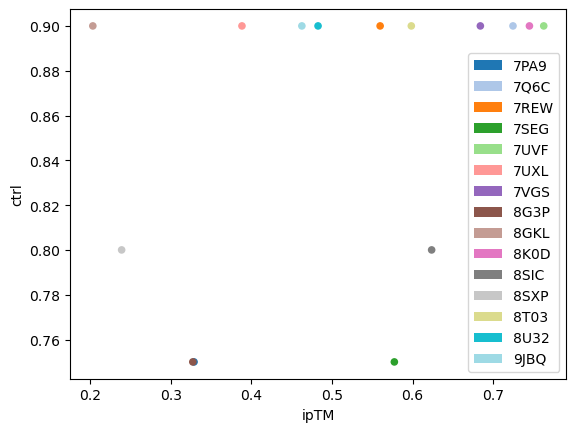

In [ ]:
df.plot("ipTM", "ctrl", kind="scatter", c="scaffold", cmap="tab20")

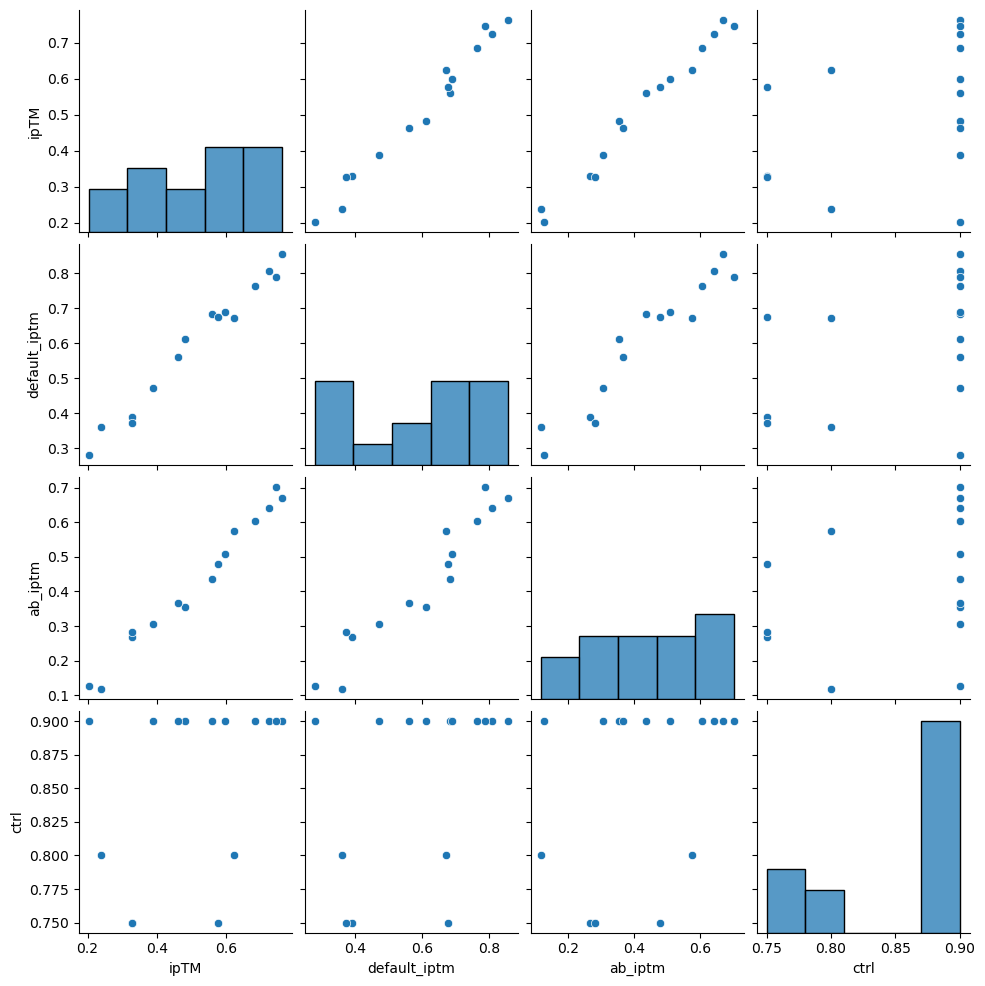

In [ ]:
sns.pairplot(df,
    )